# Weather Project

This purpose of this project is to compare precipitation and determine whether it rains more in Seattle, WA or Burlington, VT.

## Load and explore the data

### Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style('whitegrid')

## Load the data

This data comes from the National Oceanic and Atmospheric Administration  
https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

### Load the Seattle dataset

In [2]:
df_seattle  = pd.read_csv('/Users/mattejoey/Documents/MSDS-Fall-2026/DATA-5100/Projects/weather/data/seattle_rain.csv')

In [3]:
type(df_seattle)

pandas.DataFrame

### Load the Burlington dataset

In [4]:
df_burlington  = pd.read_csv('/Users/mattejoey/Documents/MSDS-Fall-2026/DATA-5100/Projects/weather/data/burlington_rain.csv')

In [5]:
type(df_burlington)

pandas.DataFrame

## Explore the contents of the datasets

### Start by looking at the head of the data

#### Seattle data

In [6]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


##### Examine more rows

In [7]:
df_seattle.head(10)

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN
5,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/6/18,NaN,NaN,0.57,NaN,NaN,NaN,NaN
6,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/7/18,NaN,NaN,0.23,NaN,NaN,NaN,NaN
7,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/8/18,NaN,NaN,0.41,NaN,NaN,NaN,NaN
8,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",3/12/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
9,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",3/13/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN


#### Burlington data

In [8]:
df_burlington.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-01,0.00,0.0,7.1
1,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-02,0.00,0.2,7.1
2,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-03,0.00,0.0,7.1
3,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-04,0.15,2.8,9.8
4,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-05,0.09,2.7,9.8


##### Examine more rows

In [9]:
df_burlington.head(10)

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-01,0.00,0.0,7.1
1,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-02,0.00,0.2,7.1
2,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-03,0.00,0.0,7.1
3,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-04,0.15,2.8,9.8
4,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-05,0.09,2.7,9.8
5,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-06,0.02,0.3,11.0
6,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-07,0.02,0.5,9.8
7,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-08,0.01,0.2,9.8
8,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-09,0.07,1.6,9.8
9,USW00014742,"BURLINGTON INTERNATIONAL AIRPORT, VT US",2018-01-10,0.00,0.0,7.9


### Are the columns the same?

In [10]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='str')

In [11]:
df_burlington.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

Seattle has four more coulmns

### Use the `info` method to check the data types, size of the data frame, and numbers of missing values.

In [12]:
df_seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [13]:
df_burlington.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 192.7 KB


### Examine the shape of each dataset

In [14]:
df_seattle.shape

(1658, 10)

In [15]:
df_burlington.shape

(1826, 6)

Seattle has 1658 rows and 10 columns while Burlington has 1826 rows and 6 columns

## Why might the Burlington dataset have more entries?

### Examine the number of stations

In [16]:
df_seattle['STATION'].nunique()

1

In [17]:
df_burlington['STATION'].nunique()

1

Both datasets have data from only 1 station

### Examine the `DATE` column

In [18]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: str

In [19]:
df_burlington['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1821    2022-12-27
1822    2022-12-28
1823    2022-12-29
1824    2022-12-30
1825    2022-12-31
Name: DATE, Length: 1826, dtype: str

### Convert `DATE` to datetime

In [20]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])

/var/folders/vh/0d9pw68j4132jv9wfznhv0km0000gn/T/ipykernel_11014/3087519436.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])


In [21]:
df_burlington['DATE'] = pd.to_datetime(df_burlington['DATE'])

In [22]:
df_seattle['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[us]

In [23]:
df_burlington['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1821   2022-12-27
1822   2022-12-28
1823   2022-12-29
1824   2022-12-30
1825   2022-12-31
Name: DATE, Length: 1826, dtype: datetime64[us]

##### `DATE` now has type datetime

### What ranges of dates are present?

In [24]:
df_seattle['DATE'].agg([min,max])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

In [25]:
df_burlington['DATE'].agg([min,max])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

##### Both datasets have dates ranging from 2018-01-01 to 2022-12-31

### Is the data suitable for answering the question?

#### Plot the daily precipitation for Seattle

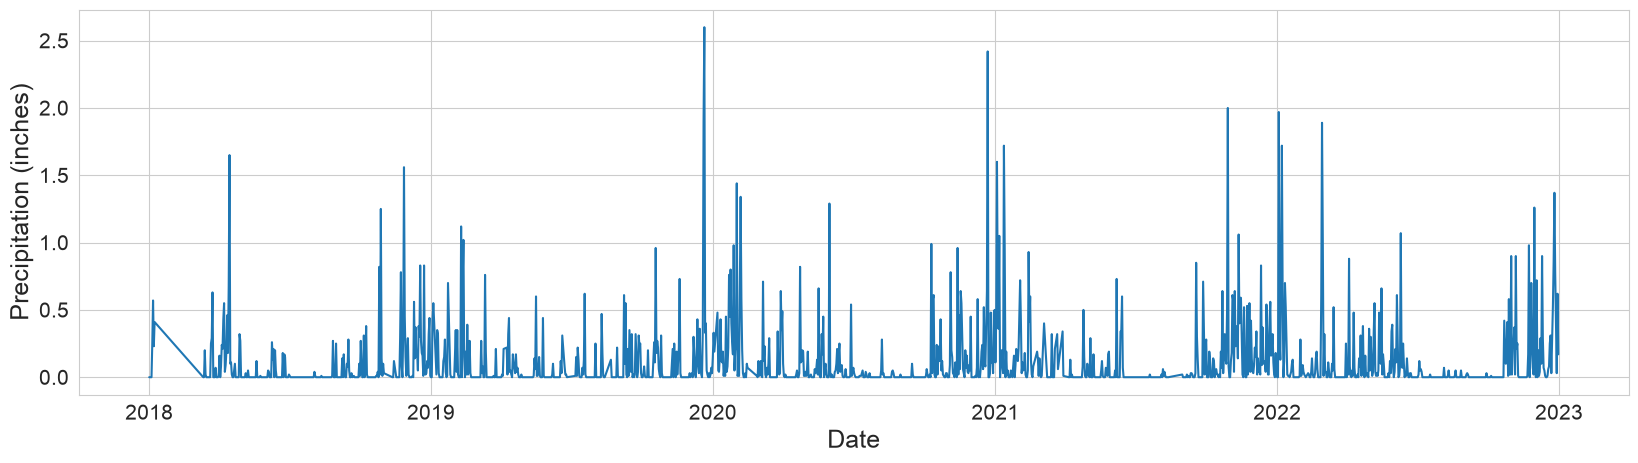

In [26]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df_seattle,x='DATE',y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

There may be gaps or null values towards the start of 2018

In [27]:
df_seattle.head(30)

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-03,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-04,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-05,NaN,NaN,0.25,NaN,NaN,NaN,NaN
5,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-06,NaN,NaN,0.57,NaN,NaN,NaN,NaN
6,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-07,NaN,NaN,0.23,NaN,NaN,NaN,NaN
7,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-08,NaN,NaN,0.41,NaN,NaN,NaN,NaN
8,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-03-12,NaN,NaN,0.00,NaN,NaN,NaN,NaN
9,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-03-13,NaN,NaN,0.00,NaN,NaN,NaN,NaN


There is a gap in the seattle dataframe from 2018-01-08 to 2018-03-12 which accounts for the missing data. This will be dealt with later

#### Plot the daily precipitation for Burlington

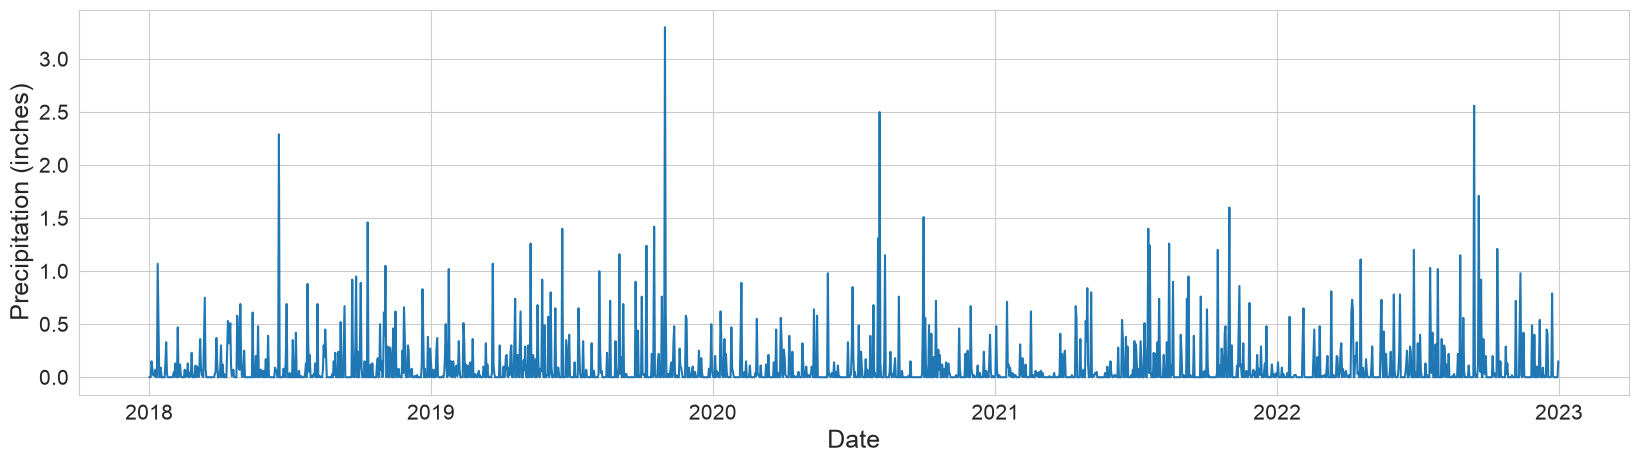

In [28]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df_burlington,x='DATE',y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

The Burlington data looks good

### Join data frames keeping `DATE` and `PRCP` columns

In [29]:
df = df_burlington[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']],on='DATE',how='outer')

In [30]:
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.15,0.00
4,2018-01-05,0.09,0.25


The data is in long format

### Create a tidy data frame with columns for city and precipitation

In [31]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [32]:
df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.15
4,2018-01-05,PRCP_x,0.09


It is now in tidy format

### Rename columns or values to follow best practices

In [33]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'BUR'

In [34]:
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

In [35]:
df.head()

,DATE,city,precipitation
0,2018-01-01,BUR,0.00
1,2018-01-02,BUR,0.00
2,2018-01-03,BUR,0.00
3,2018-01-04,BUR,0.15
4,2018-01-05,BUR,0.09


In [36]:
df = df.rename(columns={'DATE': 'date'})

In [37]:
df.head()

,date,city,precipitation
0,2018-01-01,BUR,0.00
1,2018-01-02,BUR,0.00
2,2018-01-03,BUR,0.00
3,2018-01-04,BUR,0.15
4,2018-01-05,BUR,0.09


### Count the non-null or null values

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[us]
 1   city           3652 non-null   str           
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 96.4 KB


#### Determine the number of null values in each column.

In [39]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

There are 190 null values in the precipitation column

#### Determine the number of null precipitation values for Seattle and Burlington

In [40]:
df.loc[df['city']=='SEA','precipitation'].isna().sum()

np.int64(190)

In [41]:
df.loc[df['city']=='BUR','precipitation'].isna().sum()

np.int64(0)

All of the null values come from Seattle

##### The St. Louis data set does not have any `NaN` values of `precipitation`. Are any dates omitted?

**How many data points should we have from 2018 to 2022?**

In [79]:
2 * (365 * 5 + 1) # 365 days a year, 5 years, one extra day for leap year. Times 2 because there are 2 cities

3652

No dates are omitted

### Impute missing values

#### We will replace missing values with the mean across years of values on that day.

##### Create a column called day_of_year

In [43]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [44]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,BUR,0.00,1
1,2018-01-02,BUR,0.00,2
2,2018-01-03,BUR,0.00,3
3,2018-01-04,BUR,0.15,4
4,2018-01-05,BUR,0.09,5


##### Calculate the mean precipitation for each day of the year

In [45]:
mean_day_precipitation = df.loc[df['city']=='SEA', ['precipitation', 'day_of_year']].groupby('day_of_year').mean()

##### Find the indicies that contain null values

In [46]:
indicies = np.where(df['precipitation'].isna() == True)[0]
indicies

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

##### Replace null values with the mean precipitation for that day

In [47]:
for index in indicies:
    df.loc[index,'precipitation'] = mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

##### Are there still null values?

In [48]:
df.isna().sum()

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

All the null values have been successfully replaced

## Exploratory data analysis

### Create a line plot showing daily precipitation for each city

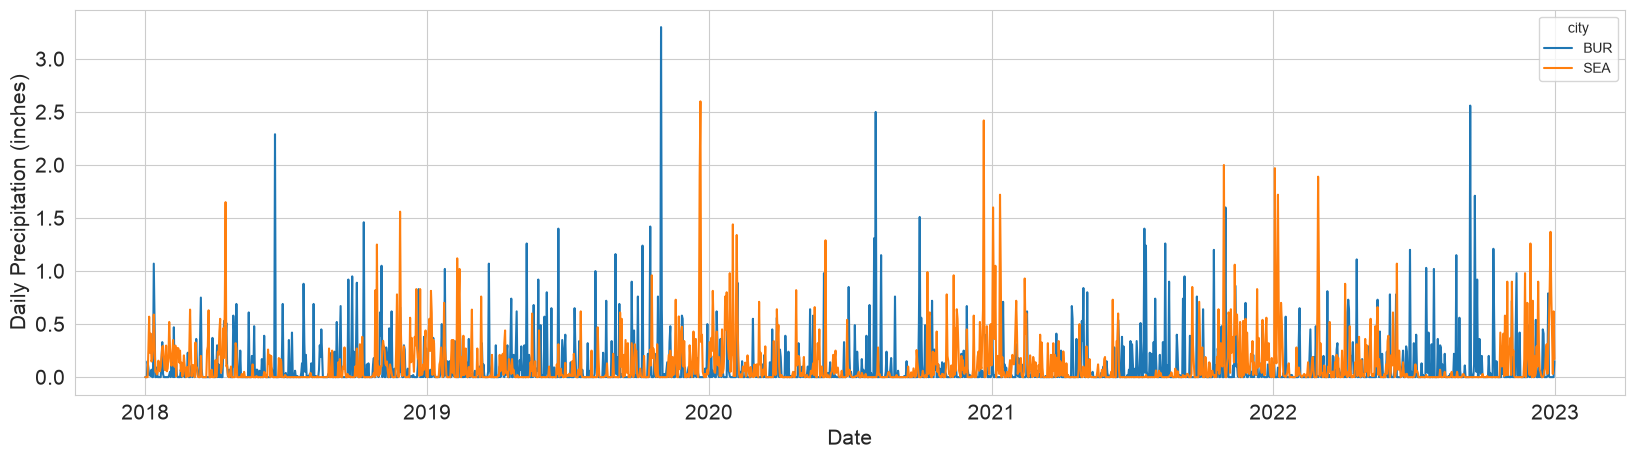

In [49]:
plt.figure(figsize = (20, 5))

sns.lineplot(data=df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

It looks like the precipitation in the two cities is fairly similar and when either has more depends on the date

### Compute basic numerical summeries for precipitation in each city

In [50]:
df[['city','precipitation']].groupby('city').describe()

precipitation                                               
             count      mean       std  min  25%   50%   75%  max
city                                                             
BUR         1826.0  0.103527  0.251347  0.0  0.0  0.00  0.07  3.3
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.6

Seattle has a slightly higher mean participation, 50%, and 75%. Burlington has a slightly higher standard deviation and maximum

### Create a barplot showing meaning daily precipitation for each city

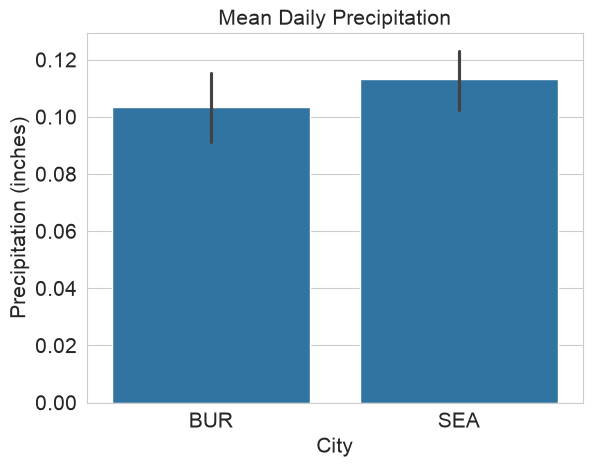

In [51]:
sns.barplot(data=df, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

### Create a new column for the month 

In [52]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [53]:
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,BUR,0.00,1,1
1,2018-01-02,BUR,0.00,2,1
2,2018-01-03,BUR,0.00,3,1
3,2018-01-04,BUR,0.15,4,1
4,2018-01-05,BUR,0.09,5,1


In [54]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

A new column called month has been created. It contains 1-12 for Jan-Dec and includes all months

### Plot the distribution of precipitation amounts each month using boxplots

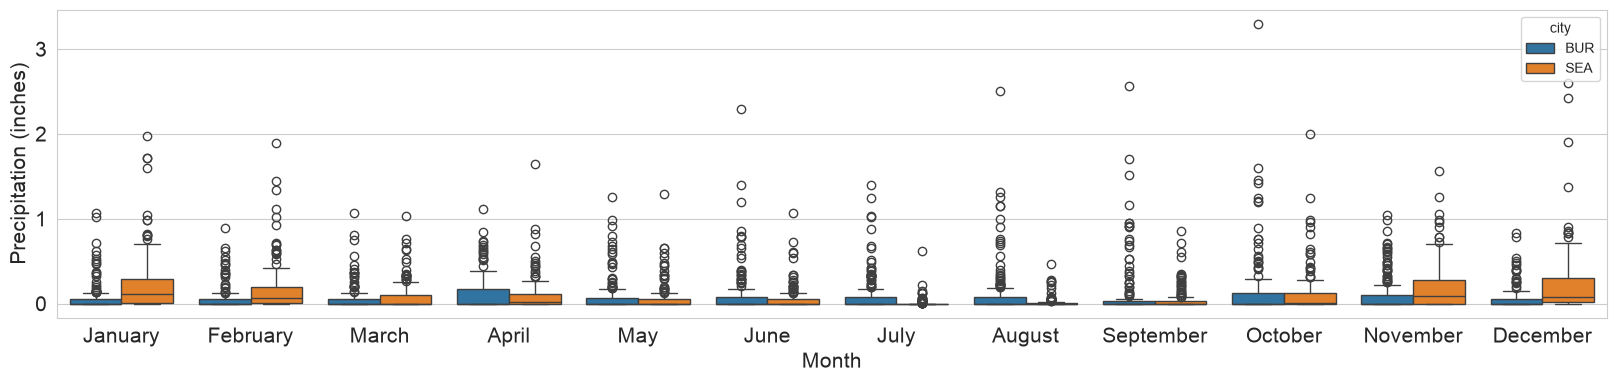

In [55]:
plt.figure(figsize=(20,4))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

# Get month names and set as x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks=range(12), labels=month_names)

plt.show()

This graph is hard to read. We will zoom in on the y axis

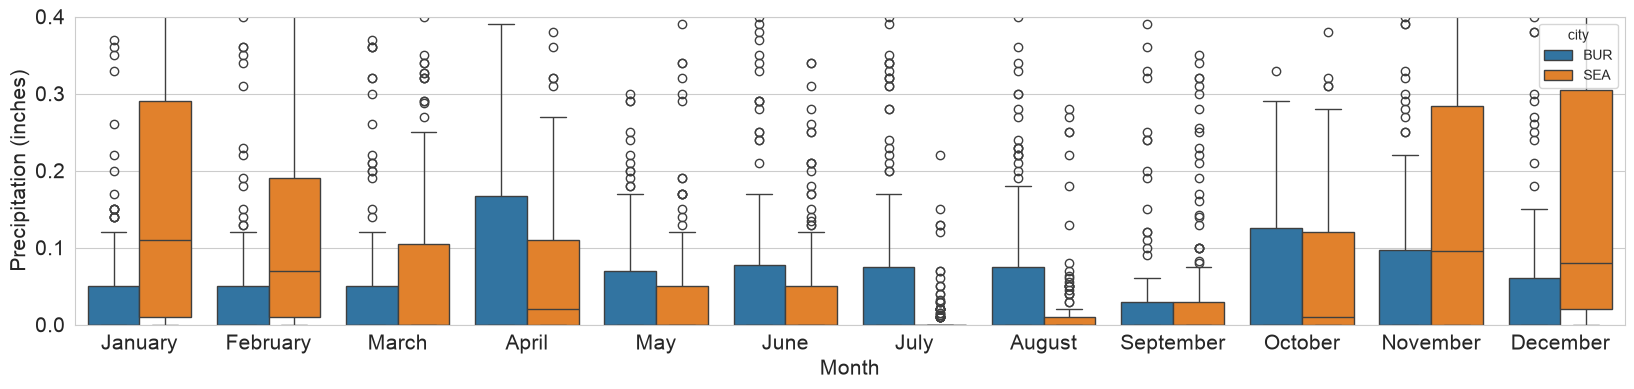

In [56]:
plt.figure(figsize=(20,4))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.ylim(0, 0.4)

plt.show()

This is much easier to read even though it leaves out some information. It looks like there is more precipitation in Seattle in Jan, Feb, Mar, Nov, and Dec and there is more in Burlington in Apr, May, Jun, Jul, and Aug

### Plot mean precipitation each month

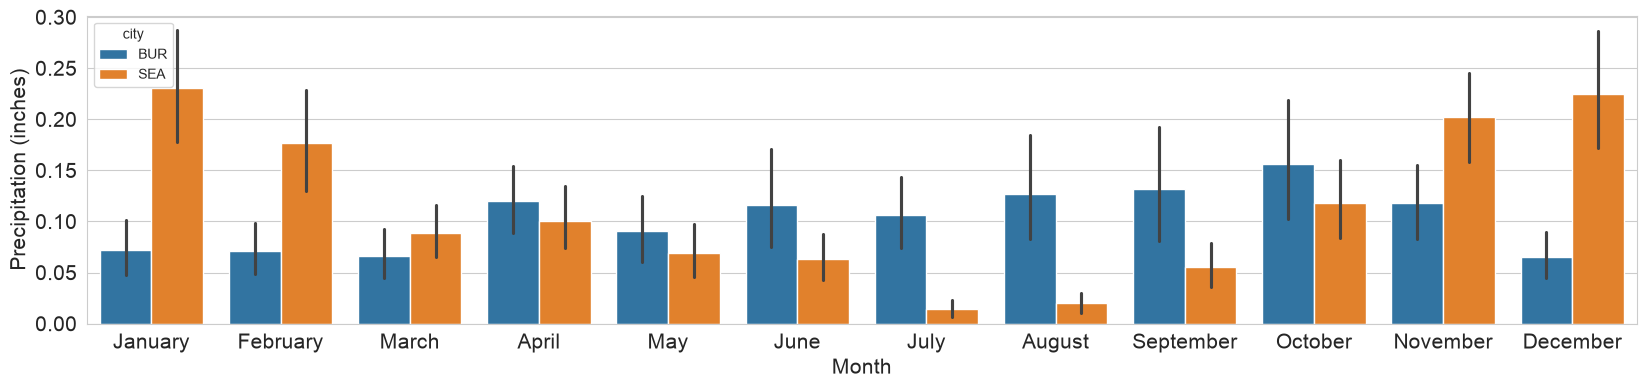

In [57]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.show()

This graph of mean precipitation each month shows Seattle to have more in Jan, Feb, Mar, Nov, and Dec and Burlington to have more in Apr, May, Jun, Jul, Aug, Sep, and Oct

### Compute the mean precipitation each month

In [58]:
df[['city','precipitation','month']].groupby(['city','month']).mean()

precipitation
city month               
BUR  1           0.071613
     2           0.070638
     3           0.066581
     4           0.120400
     5           0.090839
     6           0.116533
     7           0.106645
     8           0.127226
     9           0.131467
     10          0.156516
     11          0.118133
     12          0.065097
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

The table show Seattle to have more precipitation in Jan, Feb, Mar, Nov, and Dec and Burlington to have more in Apr, May, Jun, Jul, Aug, Sep, and Oct 

### Plot the proportion of days with any precipitation

#### We need a variable containing True/ False for if there was any precipitation that day

In [59]:
df['any_precipitation'] = df['precipitation'] > 0

In [60]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,BUR,0.00,1,1,False
1,2018-01-02,BUR,0.00,2,1,False
2,2018-01-03,BUR,0.00,3,1,False
3,2018-01-04,BUR,0.15,4,1,True
4,2018-01-05,BUR,0.09,5,1,True


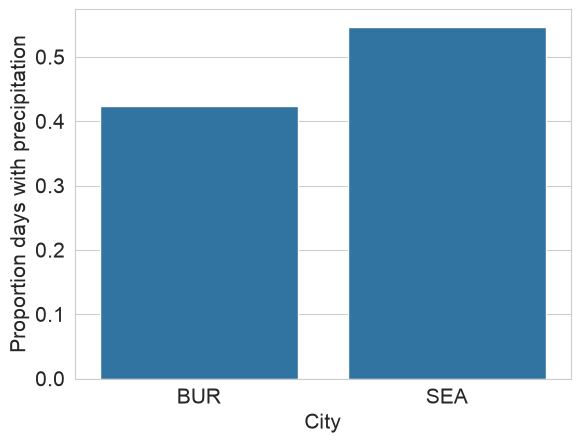

In [61]:
sns.barplot(data=df, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

Seattle has had more days with precipitation from 2018 to 2022

### Plot the proportion of days with precipitation each month

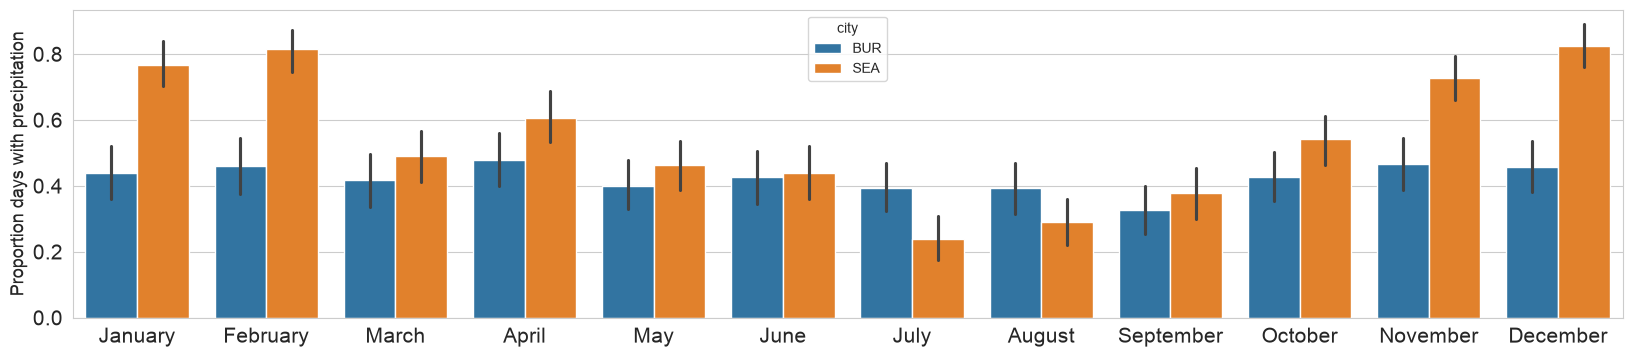

In [62]:
plt.figure(figsize= (20, 4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)

plt.show()

Seattle had more days with precipitation in every month except for July and August

## Preform a statistical test for the difference in mean precipitation between the cities

### To preform z and t tests we need to check the distribution of the data

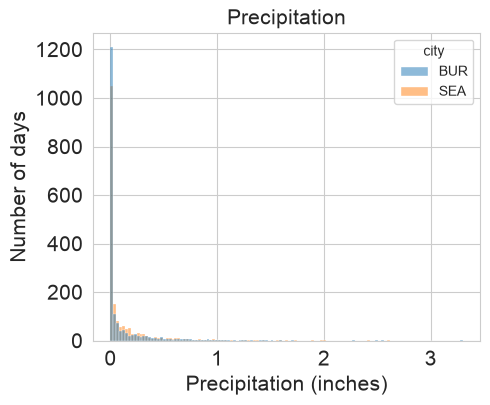

In [63]:
plt.figure(figsize=(5, 4))

sns.histplot(data=df, x='precipitation', hue='city')

plt.ylabel('Number of days', fontsize=15)
plt.xlabel('Precipitation (inches)', fontsize=15)
plt.title('Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

Even though the data is not normally distributed, it is okay to use z and t tests because of how large the sample size is

In [64]:
from scipy import stats

In [65]:
significance_level = 0.05

sea_data = df.loc[df['city'] == 'SEA', 'precipitation']
bur_data = df.loc[df['city'] == 'BUR', 'precipitation']

t_statistic, p_value = stats.ttest_ind(sea_data, bur_data, equal_var=False)

print(f" t-statistic = {t_statistic:.2f}")
print(f" p-value t test = {p_value:.3f}")

 t-statistic = 1.20
 p-value t test = 0.231


There is no significant difference in mean precipitation between the cities

## Preform a statistical test for the difference in proportion of days with precipitation between the cities

In [66]:
from statsmodels.stats.proportion import proportions_ztest

contingency_table = pd.crosstab(
    df['city'], df['any_precipitation']
)

# Calculate the number of True values for each city
days_with_precipitation = contingency_table[True]

# Calculate the total number of days for each city
total_counts = contingency_table.sum(axis=1)

# Hypothesis test
zstat, p_value = proportions_ztest(
    count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
)

print(f" zstat = {zstat:.2f}")
print(f" p_value z test = {p_value:.3f}")

 zstat = -7.45
 p_value z test = 0.000


There is a significant difference in the proportion of days with precipitation between the cities

## Preform a statistical test for differences in the mean participiation each month between the cities

In [67]:
significance_level= 0.05
significantly_different = np.zeros(12)

# Preform t-test for each month
for month in range(1,13):
    # Get participation data for Seattle and St louis for the current month
    sea_data = df.loc[(df['city']== 'SEA') & (df['month'] == month), 'precipitation']
    bur_data = df.loc[(df['city']== 'BUR') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, bur_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f" t-statistic = {t_statistic:.2f}")
    print(f" p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
 t-statistic = 5.18
 p-value t test = 0.000
--------------------
Month 2:
 t-statistic = 3.77
 p-value t test = 0.000
--------------------
Month 3:
 t-statistic = 1.23
 p-value t test = 0.220
--------------------
Month 4:
 t-statistic = -0.84
 p-value t test = 0.402
--------------------
Month 5:
 t-statistic = -1.02
 p-value t test = 0.308
--------------------
Month 6:
 t-statistic = -2.02
 p-value t test = 0.045
--------------------
Month 7:
 t-statistic = -4.81
 p-value t test = 0.000
--------------------
Month 8:
 t-statistic = -4.11
 p-value t test = 0.000
--------------------
Month 9:
 t-statistic = -2.47
 p-value t test = 0.014
--------------------
Month 10:
 t-statistic = -1.00
 p-value t test = 0.316
--------------------
Month 11:
 t-statistic = 2.90
 p-value t test = 0.004
--------------------
Month 12:
 t-statistic = 4.93
 p-value t test = 0.000
--------------------


There is a significant difference in the amount of precipitation in Jan, Feb, Jun, Jul, Aug, Sep, Nov, and Dec

### Plot the mean precipitation each month with a star for significant differences

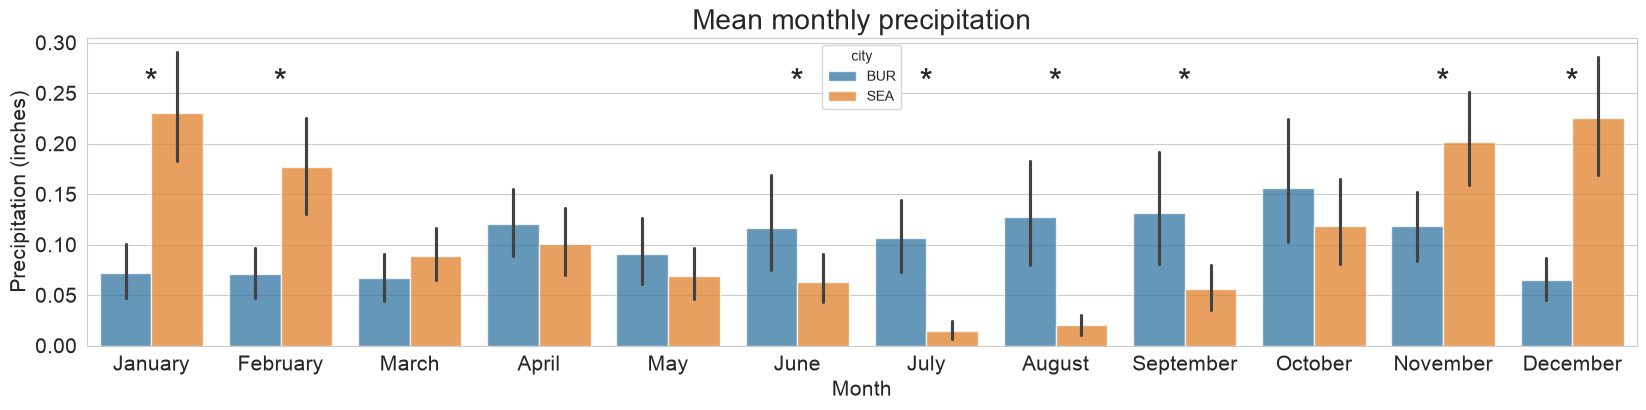

In [68]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='precipitation', hue='city', alpha=0.75)

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title('Mean monthly precipitation', fontsize=20)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:
        # Add a star
        plt.text(month, 0.25, '*', ha='center', fontsize=25)

plt.show()

The addition of the stars makes it easy to see months where there is a significant difference. From the graph I would have expected there to be in Mar, Apr, May, and Oct but there is not.

## Preform a statistical test for differences in the proportions of days with any precipitation each month between the cities

In [69]:
significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Preform z-test for each month
for month in range(1,13):
    # Create a contingency table for SEA and STL for the current month
    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation']
    )

    # Calculate the number of True values for each city
    days_with_precipitation = contingency_table[True]

    # Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)

    # Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

    print(f"Month {month}:")
    print(f" z-statistic = {zstat:.2f}")
    print(f" p-value z test = {p_value:.3f}")
    print("-" * 20)

Month 1:
 z-statistic = -5.92
 p-value z test = 0.000
--------------------
Month 2:
 z-statistic = -6.20
 p-value z test = 0.000
--------------------
Month 3:
 z-statistic = -1.25
 p-value z test = 0.210
--------------------
Month 4:
 z-statistic = -2.20
 p-value z test = 0.028
--------------------
Month 5:
 z-statistic = -1.15
 p-value z test = 0.252
--------------------
Month 6:
 z-statistic = -0.23
 p-value z test = 0.816
--------------------
Month 7:
 z-statistic = 2.93
 p-value z test = 0.003
--------------------
Month 8:
 z-statistic = 1.92
 p-value z test = 0.055
--------------------
Month 9:
 z-statistic = -0.97
 p-value z test = 0.334
--------------------
Month 10:
 z-statistic = -2.05
 p-value z test = 0.041
--------------------
Month 11:
 z-statistic = -4.59
 p-value z test = 0.000
--------------------
Month 12:
 z-statistic = -6.75
 p-value z test = 0.000
--------------------


There is a significant difference in the proportion of days with any precipitation in Jan, Feb, Apr, Jul, Oct, Nov, and Dec

### Plot the proportion of days with any precipitation each month with a star for significant differences

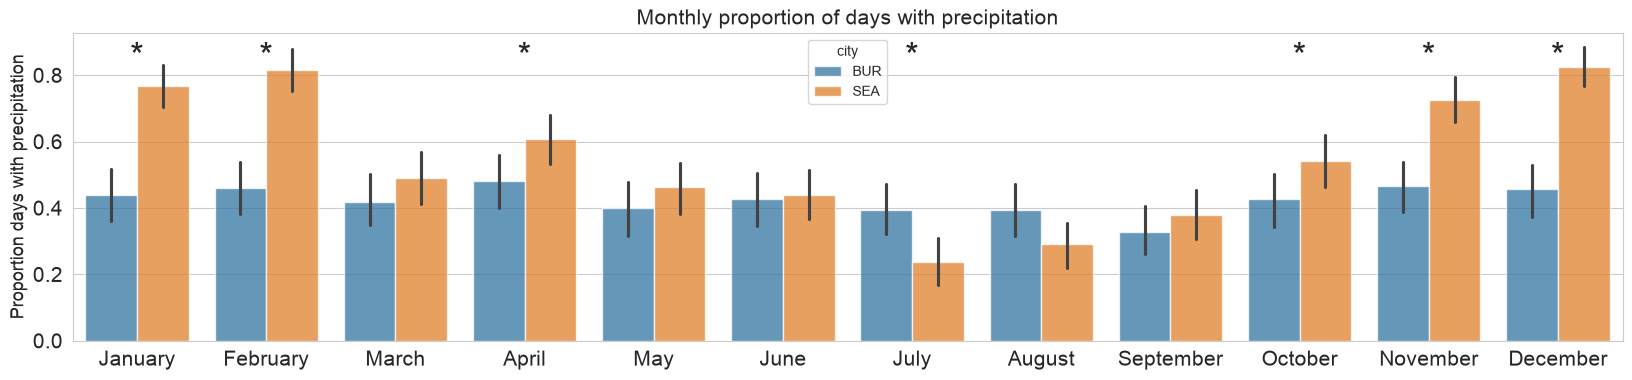

In [70]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city', alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Monthly proportion of days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month] == 1:
        # Add a star
        plt.text(month, 0.825, '*', ha='center', fontsize=25)

plt.show()

This barplot makes it easy to see months where there is a significant difference in the proportion of days with precipitation between the cities. From only looking at the graph I would have expected August to also have a significant difference

### Add a column for the season

In [71]:
df['season'] = pd.cut(
    df['month'], 
    bins=[0, 2, 5, 8, 11, 12], 
    labels=[1, 2, 3, 4, 1], 
    ordered=False
)

In [72]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation,season
0,2018-01-01,BUR,0.00,1,1,False,1
1,2018-01-02,BUR,0.00,2,1,False,1
2,2018-01-03,BUR,0.00,3,1,False,1
3,2018-01-04,BUR,0.15,4,1,True,1
4,2018-01-05,BUR,0.09,5,1,True,1


Dec, Jan, and Feb fall into season 1 (Winter). Mar, Apr, and May fall into season 2 (Spring). Jun, Jul, and Aug fall into season 3 (Summer). Sep, Oct, and Nov fall into season 4 (Fall).

### Bar plot of mean season precipitation

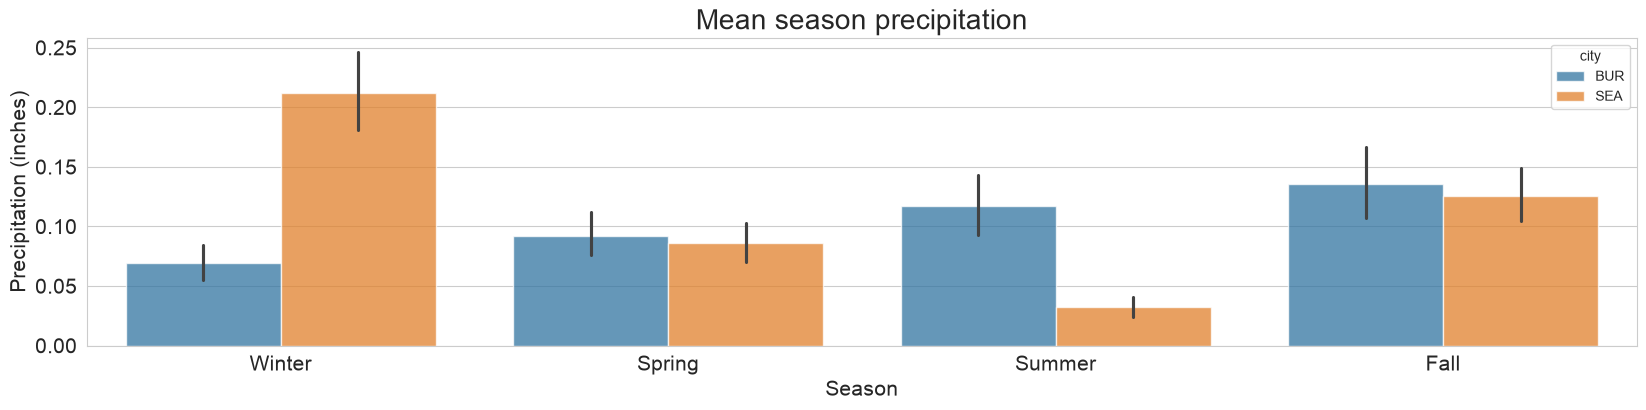

In [73]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='season', y='precipitation', hue='city', alpha=0.75)

plt.xlabel('Season', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title('Mean season precipitation', fontsize=20)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(4), labels=['Winter', 'Spring', 'Summer', 'Fall'])

plt.show()

It looks like the mean precipitation is greater in Seattle in the Winter and in Burlington in the Summer

### Preform a t test for differences in the mean precipitation each season between the cities

In [74]:
significance_level= 0.05
significantly_different_season = np.zeros(4)

# Preform t-test for each season
for season in range(1, 5):
    # Get participation data for Seattle and St louis for the current month
    sea_data = df.loc[(df['city']== 'SEA') & (df['season'] == season), 'precipitation']
    bur_data = df.loc[(df['city']== 'BUR') & (df['season'] == season), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, bur_data, equal_var=False)

    if p_value < significance_level:
        significantly_different_season[season-1] = 1
    
    print(f"Season {season}:")
    print(f" t-statistic = {t_statistic:.2f}")
    print(f" p-value t test = {p_value:.3f}")
    print("-" * 20)

Season 1:
 t-statistic = 8.07
 p-value t test = 0.000
--------------------
Season 2:
 t-statistic = -0.51
 p-value t test = 0.612
--------------------
Season 3:
 t-statistic = -6.09
 p-value t test = 0.000
--------------------
Season 4:
 t-statistic = -0.54
 p-value t test = 0.589
--------------------


There is a significant difference in the mean precipitation in Winter and Summer

### Plot the mean precipitation each season with a star for significant differences

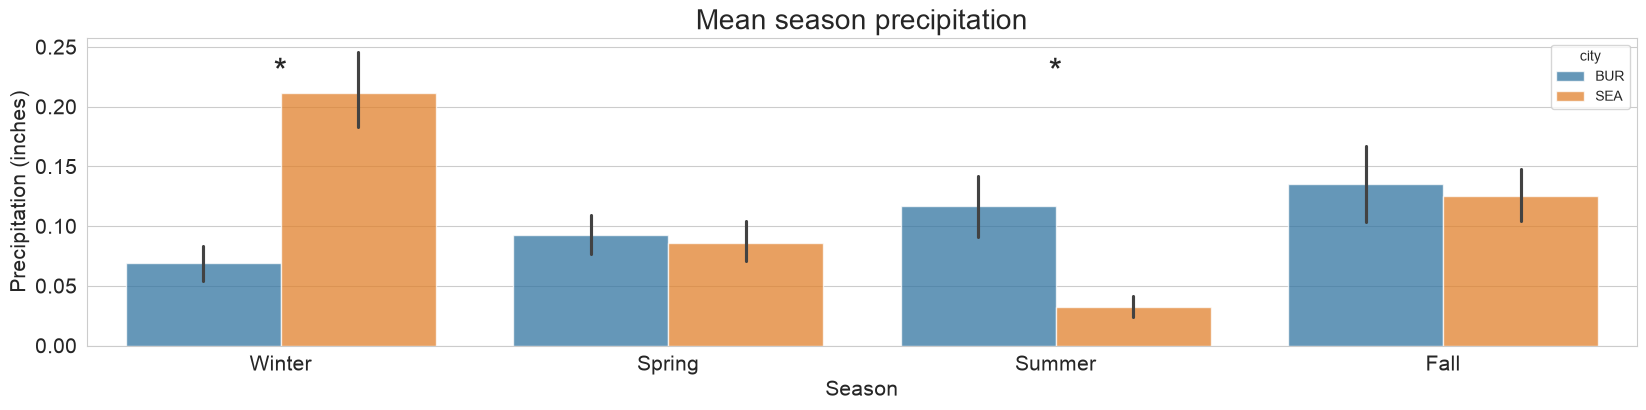

In [75]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='season', y='precipitation', hue='city', alpha=0.75)

plt.xlabel('Season', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title('Mean season precipitation', fontsize=20)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(4), labels=['Winter', 'Spring', 'Summer', 'Fall'])

# Add stars for significantly different months
for season in range(4):
    if significantly_different_season[season] == 1:
        # Add a star
        plt.text(season, 0.22, '*', ha='center', fontsize=25)

plt.show()

### Plot the proportion of days with any precipitation each season

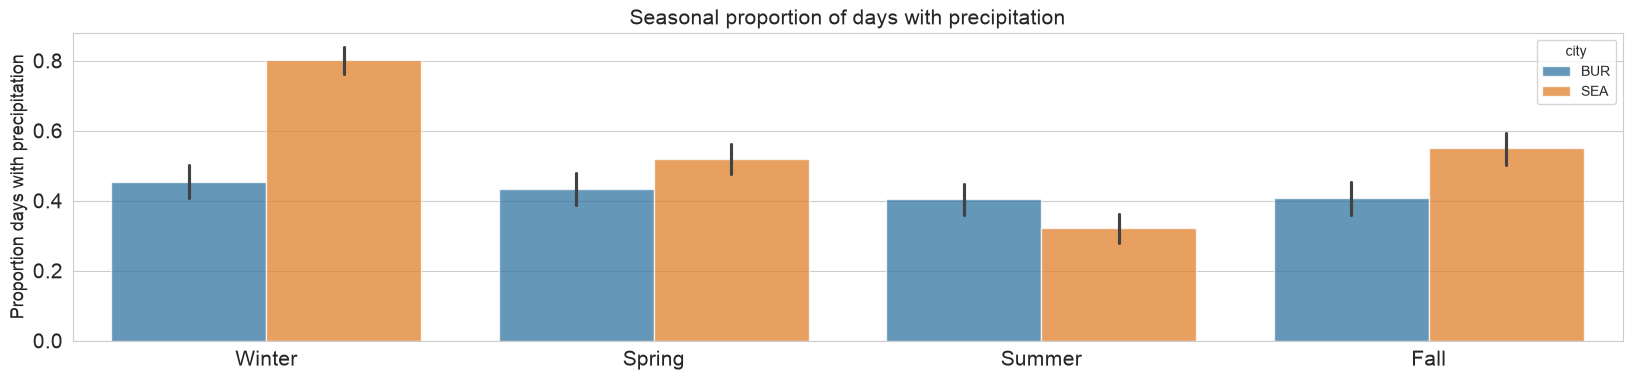

In [76]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='season', y='any_precipitation', hue='city', alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Seasonal proportion of days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(4), labels=['Winter', 'Spring', 'Summer', 'Fall'])

plt.show()

## Preform a statistical test for differences in the proportions of days with any precipitation each season between the cities

In [77]:
significance_level = 0.05
significantly_different_proportion_seasons = np.zeros(4)

# Preform z-test for each month
for season in range(1,5):
    # Create a contingency table for SEA and STL for the current season
    contingency_table = pd.crosstab(
        df.loc[df['season'] == season, 'city'], df.loc[df['season'] == season, 'any_precipitation']
    )

    # Calculate the number of True values for each city
    days_with_precipitation = contingency_table[True]
    
    # Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)
    
    # Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion_seasons[season-1] = 1

    print(f"Season {season}:")
    print(f" z-statistic = {zstat:.2f}")
    print(f" p-value z test = {p_value:.3f}")
    print("-" * 20)

Season 1:
 z-statistic = -10.88
 p-value z test = 0.000
--------------------
Season 2:
 z-statistic = -2.64
 p-value z test = 0.008
--------------------
Season 3:
 z-statistic = 2.61
 p-value z test = 0.009
--------------------
Season 4:
 z-statistic = -4.31
 p-value z test = 0.000
--------------------


There is a significant difference in the proportion of days with precipitation in all seasons

### Plot the proportion of days with any precipitation each season with a star for significant differences

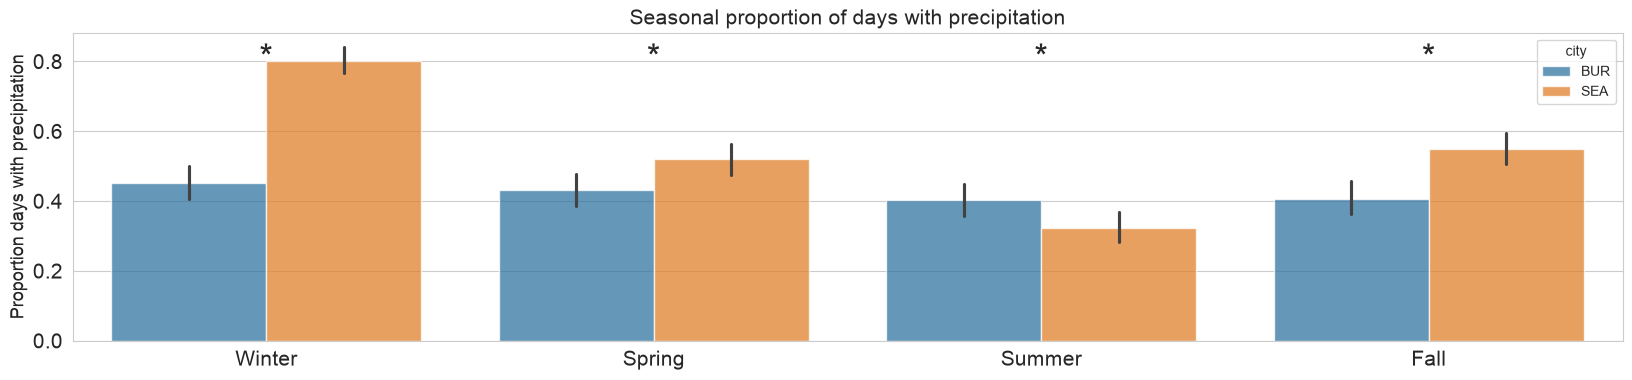

In [78]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='season', y='any_precipitation', hue='city', alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Seasonal proportion of days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(4), labels=['Winter', 'Spring', 'Summer', 'Fall'])

for season in range(4):
    if significantly_different_proportion_seasons[season] == 1:
        # Add a star
        plt.text(season, 0.78, '*', ha='center', fontsize=25)

plt.show()